# From Empricial distribution of PFES, derive PFES partitioning threshold

# 1. Load data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

final_dir = '/media/drive2/seulki/Project/Missense_2025/data/variant-2025Q4'
case = pd.read_csv(f'{final_dir}/final_case_annotation_score_vep.txt', delimiter='\t',low_memory=False)
control = pd.read_csv(f'{final_dir}/final_control_annotation_score_vep.txt', delimiter='\t',low_memory=False)

home_dir = '..'

SCORE_COLS     = ['PFES', 'PFES_Physicochemical', 'PFES_Structure',
                  'PFES_Domain', 'PFES_Modification', 'PFES_Function', 'PFES_PPI']
PRESENCE_BASED = {'PFES_Function', 'PFES_PPI'}
N_STEPS        = 10_000

print(f"Case:    {len(case):,} variants (read from {final_dir}/final_case_annotation_score_vep.txt)")
print(f"Control: {len(control):,} variants (read from {final_dir}/final_control_annotation_score_vep.txt)")

Case:    85,321 variants (read from /media/drive2/seulki/Project/Missense_2025/data/variant-2025Q4/final_case_annotation_score_vep.txt)
Control: 130,719 variants (read from /media/drive2/seulki/Project/Missense_2025/data/variant-2025Q4/final_control_annotation_score_vep.txt)


# 2. Build smoothed p-value lookup using KDE

For each score column:
- p_enriched(v) = P(X >= v | control) = 1 - KDE_CDF_control(v)
- p_depleted(v) = P(X <= v | case)    =     KDE_CDF_case(v)

In [2]:
def kde_cdf(data, values):
    """Evaluate the KDE-smoothed CDF of `data` at each point in `values`."""
    kde = stats.gaussian_kde(data)
    # Integrate from -inf to each value via cumulative trapezoid
    # Use a grid finer than `values` for accurate integration
    grid  = np.linspace(data.min() - 3 * data.std(),
                        data.max() + 3 * data.std(), 5_000)
    pdf   = kde(grid)
    cdf_grid = np.cumsum(pdf) * (grid[1] - grid[0])
    cdf_grid /= cdf_grid[-1]                          # normalise to [0, 1]
    return np.interp(values, grid, cdf_grid)          # interpolate to target values


records = []
for col in SCORE_COLS:
    c  = case[col].dropna().values
    ct = control[col].dropna().values

    if col in PRESENCE_BASED:
        records.append({'score_col': col, 'pfes_value': 0.0,
                        'p_enriched': np.nan, 'p_depleted': np.nan,
                        'presence_based': True})
        continue

    lo   = min(c.min(), ct.min())
    hi   = max(c.max(), ct.max())
    vals = np.linspace(lo, hi, N_STEPS)

    cdf_ctrl = kde_cdf(ct, vals)
    cdf_case = kde_cdf(c,  vals)

    for v, p_enr, p_dep in zip(vals, 1 - cdf_ctrl, cdf_case):
        records.append({'score_col': col, 'pfes_value': round(v, 6),
                        'p_enriched': round(float(p_enr), 6),
                        'p_depleted': round(float(p_dep), 6),
                        'presence_based': False})

lookup = pd.DataFrame(records)
lookup.to_csv(f'{home_dir}/data/pfes_pvalue_lookup.tsv', sep='\t', index=False)
print(f"Saved {len(lookup):,} rows to {home_dir}/data/pfes_pvalue_lookup.tsv")

Saved 50,002 rows to ../data/pfes_pvalue_lookup.tsv


# 3. Derive thresholds from smoothed lookup (p < 0.05)

Thresholds (p < 0.05):
                      enriched  depleted
score_col                               
PFES                     6.652    -3.359
PFES_Physicochemical     2.188    -2.286
PFES_Structure           6.574    -3.034
PFES_Domain              1.917    -2.638
PFES_Modification        1.587    -0.899
PFES_Function            0.000       NaN
PFES_PPI                 0.000       NaN


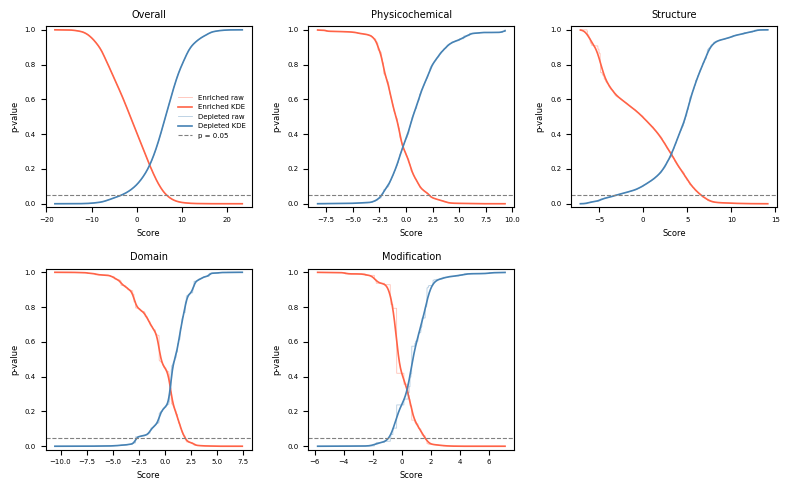

In [3]:
thresholds = {}
for col in SCORE_COLS:
    if col in PRESENCE_BASED:
        thresholds[col] = {'enriched': 0.0, 'depleted': np.nan}
        continue
    sub = lookup[lookup['score_col'] == col]
    enr = sub[sub['p_enriched'] < 0.05]['pfes_value']
    dep = sub[sub['p_depleted'] < 0.05]['pfes_value']
    thresholds[col] = {
        'enriched': enr.min() if not enr.empty else np.nan,
        'depleted': dep.max() if not dep.empty else np.nan,
    }

thresh_df = pd.DataFrame(thresholds).T
thresh_df.index.name = 'score_col'
print("Thresholds (p < 0.05):")
print(thresh_df.to_string(float_format='{:.3f}'.format))

pcols = [c for c in SCORE_COLS if c not in PRESENCE_BASED]
ncols = 3
nrows = int(np.ceil(len(pcols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(8, nrows * 2.5))
axes = axes.flatten()

for ax in axes[len(pcols):]:
    ax.set_visible(False)

for ax, col in zip(axes, pcols):
    c  = case[col].dropna().values
    ct = control[col].dropna().values

    lo   = min(c.min(), ct.min())
    hi   = max(c.max(), ct.max())
    vals = np.linspace(lo, hi, N_STEPS)

    # Raw empirical
    p_enr_raw = np.array([np.mean(ct >= v) for v in vals])
    p_dep_raw = np.array([np.mean(c  <= v) for v in vals])

    # KDE-smoothed (from lookup)
    sub       = lookup[lookup['score_col'] == col].set_index('pfes_value')
    p_enr_kde = np.interp(vals, sub.index, sub['p_enriched'])
    p_dep_kde = np.interp(vals, sub.index, sub['p_depleted'])

    ax.plot(vals, p_enr_raw, color='tomato',    lw=0.6, alpha=0.4, label='Enriched raw')
    ax.plot(vals, p_enr_kde, color='tomato',    lw=1.2,            label='Enriched KDE')
    ax.plot(vals, p_dep_raw, color='steelblue', lw=0.6, alpha=0.4, label='Depleted raw')
    ax.plot(vals, p_dep_kde, color='steelblue', lw=1.2,            label='Depleted KDE')
    ax.axhline(0.05, color='gray', lw=0.8, ls='--', label='p = 0.05')

    label = col.replace('PFES_', '')
    ax.set_title(label if label != 'PFES' else 'Overall', fontsize=7)
    ax.set_xlabel('Score', fontsize=6)
    ax.set_ylabel('p-value', fontsize=6)
    ax.tick_params(labelsize=5)
    ax.set_ylim(-0.02, 1.02)

axes[0].legend(fontsize=5, frameon=False)
plt.tight_layout()
plt.show()

# 4. Distribution histogram with smoothed thresholds

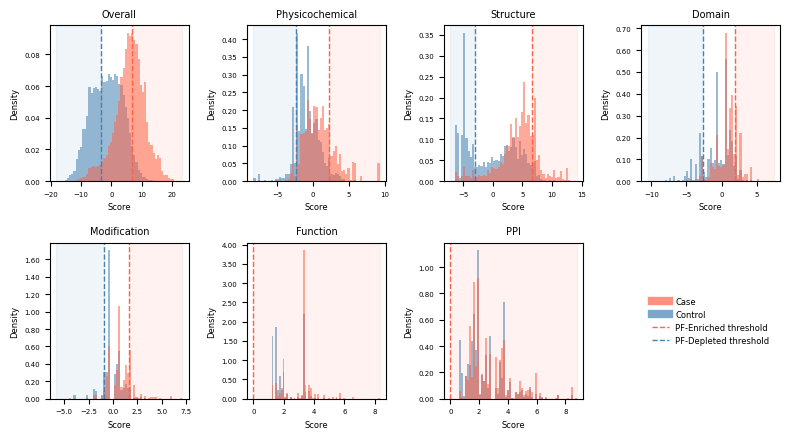

In [4]:

fig, axes = plt.subplots(2, 4, figsize=(8, 4.5))
axes = axes.flatten()

for ax, col in zip(axes, SCORE_COLS):
    c  = case[col].dropna().values
    ct = control[col].dropna().values
    t  = thresholds[col]

    lo   = min(c.min(), ct.min())
    hi   = max(c.max(), ct.max())
    bins = np.linspace(lo, hi, 60)

    ax.hist(ct, bins=bins, density=True, alpha=0.55, color='steelblue')
    ax.hist(c,  bins=bins, density=True, alpha=0.55, color='tomato')

    if not np.isnan(t['enriched']):
        ax.axvline(t['enriched'], color='tomato',    lw=1.0, ls='--')
        ax.axvspan(t['enriched'], hi, alpha=0.08, color='tomato')
    if not np.isnan(t['depleted']):
        ax.axvline(t['depleted'], color='steelblue', lw=1.0, ls='--')
        ax.axvspan(lo, t['depleted'], alpha=0.08, color='steelblue')

    label = col.replace('PFES_', '')
    ax.set_title(label if label != 'PFES' else 'Overall', fontsize=7)
    ax.set_xlabel('Score', fontsize=6)
    ax.set_ylabel('Density', fontsize=6)
    ax.tick_params(labelsize=5)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

axes[-1].axis('off')
handles = [
    plt.Line2D([0], [0], color='tomato',    alpha=0.7, lw=6, label='Case'),
    plt.Line2D([0], [0], color='steelblue', alpha=0.7, lw=6, label='Control'),
    plt.Line2D([0], [0], color='tomato',    lw=1.0, ls='--', label='PF-Enriched threshold'),
    plt.Line2D([0], [0], color='steelblue', lw=1.0, ls='--', label='PF-Depleted threshold'),
]
axes[-1].legend(handles=handles, fontsize=6, frameon=False, loc='center')

plt.tight_layout()
plt.show()